In [1]:
import numpy as np
import torch

In [2]:
from sklearn.datasets import make_blobs

In [3]:
X_np, true_label = make_blobs(n_samples=300, centers=3, random_state=42)

In [4]:
X = torch.tensor(X_np, dtype=torch.float32)

In [5]:
X.shape[0]

300

In [6]:
# idx = torch.randperm(300)
# idx[:3]

# k = X[idx[:3]]

In [7]:
# k.shape

In [8]:
def init_centroids(X, k):
    idx = torch.randperm(X.shape[0])
    three = idx[:k]
    K = X[three]

    return K

In [9]:
# centroids = init_centroids(X, 3)
# centroids

In [10]:
def assign_clusters(X, centroids):
    X = X.unsqueeze(dim=1)
    X = X - centroids

    X_new = X.pow(2).sum(dim=2)
    labels = X_new.argmin(dim=1)
    return labels

In [11]:
# centroids = init_centroids(X, 3)
# labels = assign_clusters(X, centroids)
# print(labels.shape)   # should be torch.Size([300])
# print(labels[:10])    # sanity check — should be values in {0, 1, 2}

In [12]:
# j_cluster = X[labels==1]
# j_cluster.mean(dim=0)

In [13]:
def update_centroids(X, labels, k, centroids):
    new_centroids = torch.zeros((k, X.shape[1]))

    for j in range(k):
        j_cluster = X[labels==j]
        if j_cluster.shape[0] == 0:
            new_centroids[j] = centroids[j]
        else:
            new_centroids[j] = j_cluster.mean(dim=0)

    return new_centroids

In [14]:
# new = update_centroids(X, labels, 3, centroids)
# new

In [15]:
# centroids = init_centroids(X, 3)
# labels = assign_clusters(X, centroids)
# new_centroids = update_centroids(X, labels, 3, centroids)
# print(new_centroids)

In [ ]:
def kmeans(X, k, n_iters=100, tol=1e-4):
    centroids = init_centroids(X, k)

    for i in range(n_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k, centroids)

        # convergence check goes here
        if torch.norm(centroids - new_centroids) <= tol:
            return new_centroids, labels

        centroids = new_centroids

    return centroids, labels

In [21]:
kmeans(X, 3)

(tensor([[-7.4452, -6.1765],
         [-6.4938, -7.5451],
         [ 1.0569,  5.5271]]),
 tensor([1, 0, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 0, 2, 2, 2, 2, 2, 2, 1,
         2, 0, 0, 2, 2, 2, 2, 2, 1, 2, 0, 2, 1, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2,
         1, 2, 2, 0, 1, 2, 1, 2, 1, 2, 2, 2, 0, 2, 2, 1, 0, 2, 2, 1, 0, 2, 2, 1,
         0, 2, 2, 1, 0, 2, 2, 2, 2, 2, 1, 2, 2, 1, 1, 2, 2, 2, 0, 2, 1, 2, 2, 1,
         0, 2, 1, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2,
         2, 2, 2, 1, 1, 1, 0, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 0, 2,
         2, 2, 2, 2, 2, 2, 2, 1, 2, 0, 2, 2, 2, 1, 1, 2, 2, 1, 1, 1, 2, 1, 2, 2,
         2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 0, 2, 2, 0, 2, 2, 2, 2, 0, 1,
         2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 1, 2, 2, 2, 0, 2, 2, 1, 1,
         0, 1, 2, 1, 1, 2, 1, 0, 2, 2, 0, 1, 2, 2, 2, 0, 2, 1, 2, 2, 0, 2, 1, 1,
         0, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 2, 2, 0, 2, 2, 2, 1, 2,
         2, 2, 0, 2,

In [22]:
final_centroids, final_labels = kmeans(X, k=3)
print(final_centroids)
print(final_labels[:10])

tensor([[ 4.7471,  2.0106],
        [-6.8839, -6.9840],
        [-2.6332,  9.0436]])
tensor([1, 1, 2, 0, 1, 0, 2, 0, 2, 2])


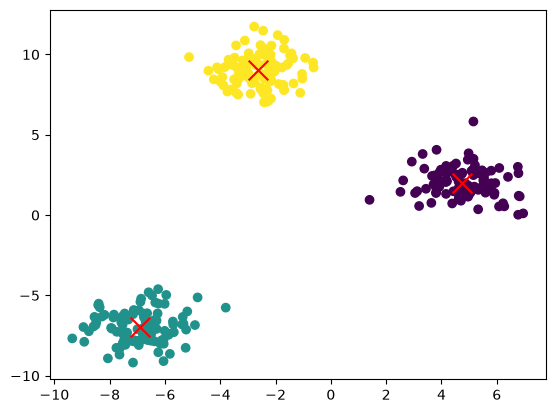

In [23]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=final_labels, cmap='viridis')
plt.scatter(final_centroids[:, 0], final_centroids[:, 1], c='red', marker='x', s=200)
plt.show()